In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
from pathlib import Path
PROJECT_ROOT = Path.cwd()

RESULTS_DIR = PROJECT_ROOT / "results"

In [3]:
import os
import numpy as np
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]
import matplotlib as mpl
import matplotlib.pyplot as plt


mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.spines.top": False,
    "axes.spines.right": False,
})
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"




# Figure 2

In [4]:
from analysis.single_task_plotting_utils import _collect_runs, average_and_plot_runs, average_and_plot_runs_multitask
single_task_DMS_DIR = RESULTS_DIR / "single_task/dms_multistyle_repeats"
single_task_PARITY_DIR = RESULTS_DIR / "single_task/parity_multistyle_repeats"


## Fig 2a

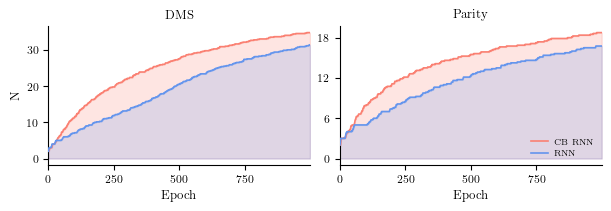

In [48]:

groups = {
    "CB RNN": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult_net",
        "color": "salmon"
    },
    "RNN": {
        "pattern": "elman_size_202_noCB",
        "color": "cornflowerblue"
    },
}

task_dirs = {
    "DMS": single_task_DMS_DIR,
    "Parity": single_task_PARITY_DIR,
}

clip_lens = {
    "DMS": 1000,
    "Parity": 1000,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity",
}

task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss",
    plot_lower_metric=False,
    log_y2=True,
    sharey_top=False,
    shade_auc=True,
    figsize=(6,2),
    fig_height=1.1,
    shade_sem=False,
    sharey_bottom=True,
    big_font=False,
    save_path=None
)


## Fig 2b

DMS | CB GC 64, lr 0.01, CB input | pattern=gc64_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=5
DMS | CB GC 128, lr 0.01, CB input | pattern=gc128_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=3
DMS | CB GC 256, lr 0.01, CB input | pattern=gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=8
DMS | CB GC 512, lr 0.01, CB input | pattern=gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=3
DMS | RNN 128 (match 64), lr 0.01 | pattern=size_128 | n=3
DMS | RNN 160 (match 128), lr 0.01 | pattern=size_160 | n=3
DMS | RNN 202 (match 256), lr 0.01 | pattern=size_202 | n=8
DMS | RNN 272 (match 512), lr 0.01 | pattern=size_272 | n=3
Parity | CB GC 64, lr 0.01, CB input | pattern=gc64_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=5
Parity | CB GC 128, lr 0.01, CB input | pattern=gc128_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=3
Parity | CB GC 256, lr 0.01, CB input | pattern=gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=8
Parity | CB GC 512, lr 0.01, CB input | pattern=gc512_RN

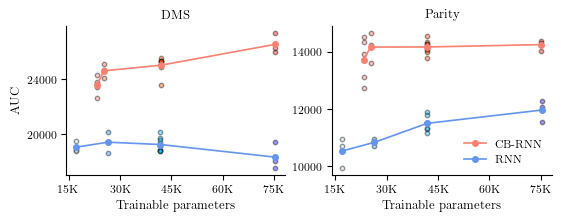

In [49]:
from analysis.scaling import plot_cb_vs_rnn_auc_scaling
CB_groups = {
    "CB GC 64, lr 0.01, CB input": {
        "pattern": "gc64_RNNlr0.01_CBlr0.01_CBinput_simult_network_",
        "color": "lightcoral",
    },
    "CB GC 128, lr 0.01, CB input": {
        "pattern": "gc128_RNNlr0.01_CBlr0.01_CBinput_simult_network_",
        "color": "tomato",
    },
    "CB GC 256, lr 0.01, CB input": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_",
        "color": "orangered",
    },
    "CB GC 512, lr 0.01, CB input": {
        "pattern": "gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_",
        "color": "red",
    },
}

RNN_groups = {
    "RNN 128 (match 64), lr 0.01": {
        "pattern": "size_128",
        "color": "lightblue",
    },
    "RNN 160 (match 128), lr 0.01": {
        "pattern": "size_160",
        "color": "dodgerblue",
    },
    "RNN 202 (match 256), lr 0.01": {
        "pattern": "size_202",
        "color": "deepskyblue",
    },
    "RNN 272 (match 512), lr 0.01": {
        "pattern": "size_272",
        "color": "blue",
    },
}

all_groups = {}
all_groups.update(CB_groups)
all_groups.update(RNN_groups)
fig, axes = plot_cb_vs_rnn_auc_scaling(
    task_configs=[
        {"task_dir": single_task_DMS_DIR,    "groups": all_groups, "task_name": "DMS"},
        {"task_dir": single_task_PARITY_DIR, "groups": all_groups, "task_name": "Parity"},    
        ],
    fig_height=2.1,
    big_fonts=False,
    save_path=None
)



# Figure 3

In [50]:
multitask_dir = RESULTS_DIR / "multi_task"
switch_dir = RESULTS_DIR / "task_switch"
from analysis.multitask_switching_plotting_utils import plot_multitask_and_switching_combined, _plot_shared_N_progression_on_ax

## Fig 3a

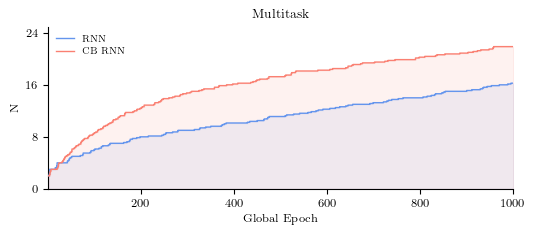

In [54]:
from pathlib import Path
import matplotlib.pyplot as plt
from analysis.multitask_switching_plotting_utils import _plot_shared_N_progression_on_ax,_plot_task_switch_N_only_on_axes

multitask_dir = Path(multitask_dir)

def find_run_dirs(substr,dir=multitask_dir):
    return sorted(d for d in dir.iterdir() if d.is_dir() and substr in d.name)

rnn_dirs = find_run_dirs("elman_size_202_noCB")
cb_dirs = find_run_dirs("gc256_RNNlr0.01_CBlr0.01_CBinput_MULTITASK_net")

fig, ax = plt.subplots(figsize=(6.0, 2.1))
_plot_shared_N_progression_on_ax(
    ax=ax,
    path_no_cb=rnn_dirs,
    path_cb=cb_dirs,
    path_cb_affix="CB RNN",
    shade_auc=True,
    show_sem=False,
    representative_task=None, 
    title="Multitask",
    big_fonts=False,
    save_path=None
)
plt.show()


## Fig 3b

In [55]:
from analysis.multitask_switching_plotting_utils import _plot_task_switch_global_progression_on_ax
task_switch_dir = Path(switch_dir)

rnn_dirs = find_run_dirs("elman_size_202_noCB", dir=task_switch_dir)
cb_dirs = find_run_dirs("gc256_RNNlr0.01_CBlr0.01_CBinput_CTSWITCH_net", dir=task_switch_dir)


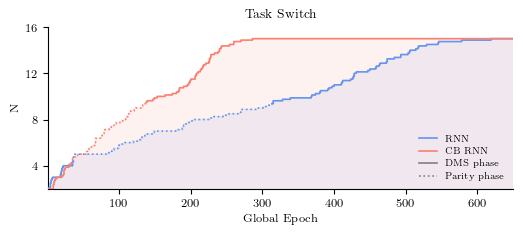

In [56]:
fig, ax = plt.subplots(figsize=(6.0, 2.1))
_plot_task_switch_global_progression_on_ax(
    ax,
    rnn_dirs, cb_dirs, None,
    affix_cb="CB RNN",
    big_fonts=False, xlim=650,
    phase_display="none",
    title=True,
    shade_auc=True, show_sem=False,
    save_path=None,
)
plt.show()


# Figure 4

## Fig 4a

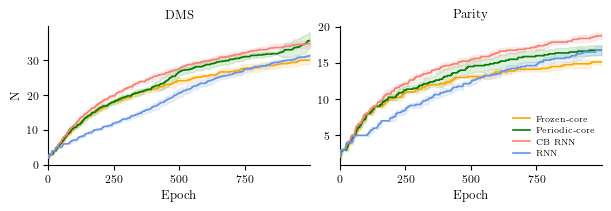

In [57]:
reservoir_dir = RESULTS_DIR / "reservoir_comparisons"
dms_path = reservoir_dir / "dms"
parity_path = reservoir_dir / "parity"
groups = {
    "Frozen-core": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only",
        "color": "orange"
    },
    "Periodic-core": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_res_n",
        "color": "green"
    },
    "CB RNN": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult",
        "color": "salmon"
    },

     "RNN": {
        "pattern": "elman_size_202_noCB",
        "color": "cornflowerblue"
    },
}

task_dirs = {
    "DMS": dms_path,
    "Parity": parity_path,
}

clip_lens = {
    "DMS": None,
    "Parity": None,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity"
}

task_aggs, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    plot_metric2="loss", 
    log_y2=True,
    figsize=(6,2),
    sharey_top=False,
    sharey_bottom=True,
    fig_height=1.1,
    big_font=False,
    save_path=None
)

## Fig 4b

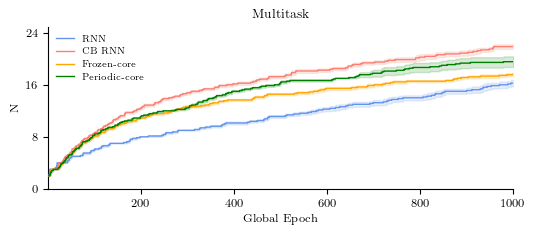

In [58]:
from analysis.multitask_switching_plotting_utils import _plot_shared_N_progression_on_ax,_plot_task_switch_N_only_on_axes

multitask_dir = Path(multitask_dir)
rnn_dirs = find_run_dirs("elman_size_202_noCB")
cb_dirs = find_run_dirs("gc256_RNNlr0.01_CBlr0.01_CBinput_MULTITASK_net")
cb_dirs_global_res = find_run_dirs("gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_MULTITASK_net")
cb_dirs_interleaved_res = find_run_dirs("gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_reservoir_MULTITASK_net")

fig, ax = plt.subplots(figsize=(6.0, 2.1))
_plot_shared_N_progression_on_ax(
    ax=ax,
    path_no_cb=rnn_dirs,
    path_cb=cb_dirs,
    path_cb_affix="CB RNN",
    path_cb_2=cb_dirs_global_res,
    path_cb_2_affix="Frozen-core",
    path_cb_3=cb_dirs_interleaved_res,
    path_cb_3_affix="Periodic-core",
    shade_auc=False,
    show_sem=True,
    representative_task=None, 
    title="Multitask",
    big_fonts=False,
    save_path=None
)
plt.show()


## Fig 4c

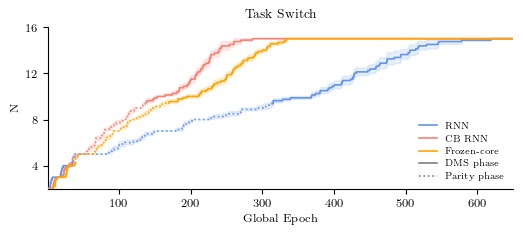

In [59]:
task_switch_dir = Path(switch_dir)

rnn_dirs = find_run_dirs("elman_size_202_noCB", dir=task_switch_dir)
cb_dirs = find_run_dirs("gc256_RNNlr0.01_CBlr0.01_CBinput_CTSWITCH_net", dir=task_switch_dir)
cb_dirs_global_res = find_run_dirs("gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_CTSWITCH_net", dir=task_switch_dir)
fig, ax = plt.subplots(figsize=(6.0, 2.1))
_plot_task_switch_global_progression_on_ax(
    ax,
    rnn_dirs, cb_dirs, cb_dirs_global_res,
    affix_cb="CB RNN", affix_cb_2="Frozen-core",
    big_fonts=False, xlim=650,
    phase_display="none",
    title=True,
    save_path=None
)
plt.show()


# Figure 5

In [14]:
from pathlib import Path
import pandas as pd

from analysis.cb_ablation import (
    compare_cb_ablation_many_runs,
    summarize_cb_ablation_many_runs,
    evaluate_rnnonly_many_runs,
    summarize_rnnonly_many_runs,
)

from tasks.task_generators import make_batch_mtstyle_dms, make_batch_mtstyle_parity


NETWORKS = range(1, 9) 

COMMON_KWARGS = dict(
    batch_size=64,
    n_batches=20,
    head_idx=0,
    device="cpu",
)


def make_network_paths(base_dir, pattern, networks=NETWORKS):
    base_dir = RESULTS_DIR / base_dir
    return [str(base_dir / pattern.format(i=i)) for i in networks]


RUN_GROUPS = {
    "dms": {
        "batch_fn": make_batch_mtstyle_dms,
        "cb_paths": make_network_paths(
            "reservoir_comparisons/dms",
            "single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "rnn_paths": make_network_paths(
            "single_task/dms_multistyle_repeats",
            "single_dms_elman_size_202_noCB_RNNlr0.01_network_{i}",
        ),
    },

    "parity": {
        "batch_fn": make_batch_mtstyle_parity,
        "cb_paths": make_network_paths(
            "reservoir_comparisons/parity",
            "single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "rnn_paths": make_network_paths(
            "single_task/parity_multistyle_repeats",
            "single_parity_elman_size_202_noCB_RNNlr0.01_network_{i}",
        ),
    },
}

In [15]:
cb_ablation_dfs = {}
cb_ablation_summary_dfs = {}

rnnonly_dfs = {}
rnnonly_summary_dfs = {}

for task, cfg in RUN_GROUPS.items():
    print(f"\nRunning CB ablation analysis: task={task}")

    df_cb = compare_cb_ablation_many_runs(
        run_paths=cfg["cb_paths"],
        batch_fn=cfg["batch_fn"],
        **COMMON_KWARGS,
    )
    df_cb["task"] = task

    df_cb_summary = summarize_cb_ablation_many_runs(df_cb)
    df_cb_summary["task"] = task

    cb_ablation_dfs[task] = df_cb
    cb_ablation_summary_dfs[task] = df_cb_summary

    print(f"Running RNN-only evaluation: task={task}")

    df_rnn = evaluate_rnnonly_many_runs(
        run_paths=cfg["rnn_paths"],
        batch_fn=cfg["batch_fn"],
        **COMMON_KWARGS,
    )
    df_rnn["task"] = task

    df_rnn_summary = summarize_rnnonly_many_runs(df_rnn)
    df_rnn_summary["task"] = task

    rnnonly_dfs[task] = df_rnn
    rnnonly_summary_dfs[task] = df_rnn_summary


Running CB ablation analysis: task=dms
[1/8] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=2
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=3
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=4
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=5
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=6
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=7
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=8
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=9
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=10
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=11
single_dms_elman_size_64_CB_gc256_

## Fig 5b-c

DMS: mean change = -0.3758, std = 0.0896
Parity: mean change = -0.4505, std = 0.0990


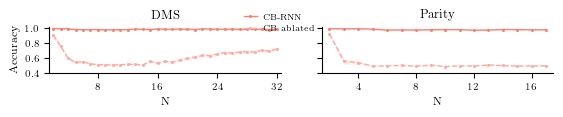

In [ ]:
df_ablate_cb = cb_ablation_dfs["dms"]
df_ablate_cb_summary = cb_ablation_summary_dfs["dms"]

df_rnnonly_dms = rnnonly_dfs["dms"]
df_rnnonly_dms_summary = rnnonly_summary_dfs["dms"]

df_ablate_cb_parity = cb_ablation_dfs["parity"]
df_ablate_cb_parity_summary = cb_ablation_summary_dfs["parity"]

df_rnnonly_parity = rnnonly_dfs["parity"]
df_rnnonly_parity_summary = rnnonly_summary_dfs["parity"]

from analysis.cb_ablation import plot_cb_ablation_two_panel
fig, axs = plot_cb_ablation_two_panel(
    df_dms_ablate=df_ablate_cb_summary,
    df_dms_rnn=df_rnnonly_dms_summary,
    df_parity_ablate=df_ablate_cb_parity_summary,
    df_parity_rnn=df_rnnonly_parity_summary,
    fig_height=2.1,
    fig_size=(6.0, 2.1),
    save_path=None
)

# report mean and std of accuracy change due to ablation
def mean_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return np.nanmean(x), np.nanstd(x)
dms_mean, dms_std = mean_std(df_ablate_cb_summary["acc_cb_ablated_mean"] - df_ablate_cb_summary["acc_full_mean"])
par_mean, par_std = mean_std(df_ablate_cb_parity_summary["acc_cb_ablated_mean"] - df_ablate_cb_parity_summary["acc_full_mean"])
print(f"DMS: mean change = {dms_mean:.4f}, std = {dms_std:.4f}")
print(f"Parity: mean change = {par_mean:.4f}, std = {par_std:.4f}")

## Fig 5d-e

In [17]:
from analysis.cb_ablation import (
    evaluate_many_runs_over_Ns_with_shared_fixed_batches,
    plot_hidden_class_points_two_tasks_tsne_1row4,
    find_available_Ns
)

dms_run_paths = [reservoir_dir/ f"dms/single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}" for i in range(1, 9)]
par_run_paths = [reservoir_dir/ f"parity/single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}" for i in range(1, 9)]  

shared_Ns_dms = set(find_available_Ns(dms_run_paths[0]))
for run_path in dms_run_paths[1:]:
    shared_Ns_dms = shared_Ns_dms.intersection(set(find_available_Ns(run_path)))
shared_Ns_dms = sorted(list(shared_Ns_dms))
print(f"Shared Ns across DMS runs: {shared_Ns_dms}")
dms_Ns = [N for N in shared_Ns_dms if N in [24]]
shared_Ns_par = set(find_available_Ns(par_run_paths[0]))
for run_path in par_run_paths[1:]:
    shared_Ns_par = shared_Ns_par.intersection(set(find_available_Ns(run_path)))
shared_Ns_par = sorted(list(shared_Ns_par))
print(f"Shared Ns across Parity runs: {shared_Ns_par}")
par_Ns = [N for N in shared_Ns_par if N in [8]]


df_ablation_dms, all_outputs_dms, fixed_batches_by_N = evaluate_many_runs_over_Ns_with_shared_fixed_batches(
    run_paths=dms_run_paths,
    batch_fn=make_batch_mtstyle_dms,
    Ns=dms_Ns,
    batch_size=64,
    n_batches=10,
    head_idx=0,
    device="cpu",
    return_outputs=True,
)

df_ablation_par, all_outputs_par, fixed_batches_by_N = evaluate_many_runs_over_Ns_with_shared_fixed_batches(
    run_paths=par_run_paths,
    batch_fn=make_batch_mtstyle_parity,
    Ns=par_Ns,
    batch_size=64,
    n_batches=10,
    head_idx=0,
    device="cpu",
    return_outputs=True,
)


Shared Ns across DMS runs: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
Shared Ns across Parity runs: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
[1/8] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=24


[2/8] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2 | N=24
[3/8] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_3
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_3 | N=24
[4/8] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_4
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_4 | N=24
[5/8] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_5
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_5 | N=24
[6/8] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_6
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_6 | N=24
[7/8] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_7
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_net

task1: linear readout acc  Full (CV) = 0.978, Full-fitted classifier on Ablated = 0.614
task2: linear readout acc  Full (CV) = 0.978, Full-fitted classifier on Ablated = 0.495
DMS: view elev=10.0, azim=89.0 (line-separability of Full panel: 0.984)
Parity: view elev=10.0, azim=89.0 (line-separability of Full panel: 0.991)


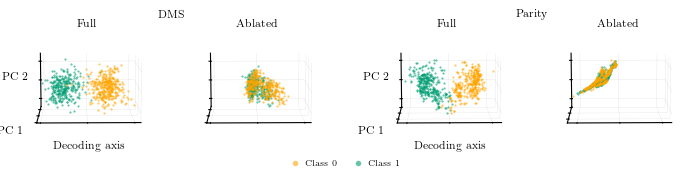

In [18]:
from analysis.cb_ablation import (
    compute_two_tasks_supervised_3d_projections,
    plot_hidden_class_points_two_tasks_tsne_3d_1row4 as plot3d,
)
dms_run_id = list(all_outputs_dms.keys())[1]
parity_run_id = list(all_outputs_par.keys())[1]

projs_sup = compute_two_tasks_supervised_3d_projections(
    all_outputs_dms, dms_run_id, 24,
    all_outputs_par, parity_run_id, 8,
)
fig, axs = plot3d(
    projections=projs_sup, elev=10, azim=89,
    big_fonts=False, figsize=(7.3, 1.6), layout="1x4", x_stretch=1.3, point_size=2.5,
    save_path=None
)


# Figure 6

In [19]:
from analysis.mechanism_plots import (
    plot_dms_memory_dynamics,
    plot_parity_causal_bar,
    plot_parity_causal_by_N,
    parity_causal_seed_summary,
)

## Fig 6a-b

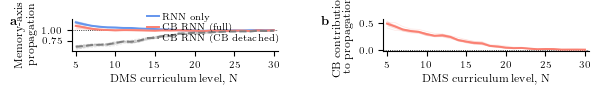

In [20]:
fig, axs = plot_dms_memory_dynamics(save_dir=None)
plt.show()

## Fig 6c

            mean      sd  n_seeds
Correct   0.9845  0.0025        8
No CB     0.0709  0.0070        8
Same      0.8252  0.0350        8
Opposite -0.7195  0.0259        8


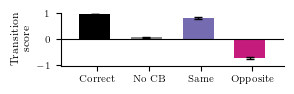

In [ ]:
fig, ax = plot_parity_causal_bar(save_dir=None) 
plt.show()

## Fig 6d

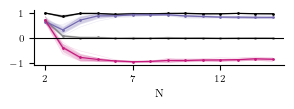

In [22]:
fig, ax = plot_parity_causal_by_N(save_dir=None)
plt.show()

# Appendices

## Appendix A

### Table 1

In [23]:
import json
configs ={
    "CB-RNN": RESULTS_DIR / "single_task" / "dms_multistyle_repeats" /"single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1"/"config.json",
    "RNN-only": RESULTS_DIR / "single_task" / "dms_multistyle_repeats" /"single_dms_elman_size_202_noCB_RNNlr0.01_network_1"/"config.json",
    "Full reservoir CB-RNN": RESULTS_DIR / "reservoir_comparisons" / "dms" /"alternating_dms_elman_size_64_CB_gc128_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_1"/"config.json",
}
for model_name, config_cb in configs.items():
    with open(config_cb, "r") as f:
        config_cb_data = json.load(f)
        print(f"{model_name} trainable parameters: {config_cb_data['model_config']['params']['trainable']}")

CB-RNN trainable parameters: 41922
RNN-only trainable parameters: 41816
Full reservoir CB-RNN trainable parameters: 25282


## Appendix C

### Table 2

In [24]:
# GRU performance stats
from analysis.learning_metrics import analyse_single_task_groups,analyse_multitask_groups,analyse_switch_groups
GRU_DMS_DIR = RESULTS_DIR / "GRU_test/dms"
GRU_parity_DIR = RESULTS_DIR / "GRU_test/parity"

groups = {
    "CB GRU": {
        "pattern": "gru_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput",
        "color": "salmon"
    },
    "GRU": {
        "pattern": "gru_size_128_noCB",
        "color": "cornflowerblue"
    },
}

task_dirs = {
    "DMS": GRU_DMS_DIR,
    "Parity": GRU_parity_DIR,
}

clip_lens = {
    "DMS": 500,
    "Parity": 500,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity",
}
CB_runpaths = [
    GRU_DMS_DIR / "single_dms_gru_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_network_1",
    GRU_DMS_DIR / "single_dms_gru_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_network_2",
    GRU_DMS_DIR / "single_dms_gru_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_network_3"
]
rnn_runpaths = [
    GRU_DMS_DIR / "single_dms_gru_size_128_noCB_RNNlr0.01_network_1",
    GRU_DMS_DIR / "single_dms_gru_size_128_noCB_RNNlr0.01_network_2",
    GRU_DMS_DIR / "single_dms_gru_size_128_noCB_RNNlr0.01_network_3"
]


gru_stat_groups = {
    "CB-GRU": CB_runpaths,
    "GRU-only": rnn_runpaths,
}

single = analyse_single_task_groups(
    gru_stat_groups,
    filename="stats.npy",      
    epoch_budget=500,         
)

display(single["summary"])
print("Global max N:", single["global_max_N"])


,model,n_runs,max_N_mean,max_N_sd,max_N_sem,final_N_mean,final_N_sd,final_N_sem,epochs_to_half_global_max_N_mean,epochs_to_half_global_max_N_sd,epochs_to_half_global_max_N_sem,raw_AUC_mean,raw_AUC_sd,raw_AUC_sem,mean_N_mean,mean_N_sd,mean_N_sem
0,CB-GRU,3,32.333333,0.577350,0.333333,32.333333,0.577350,0.333333,141.666667,6.110101,3.527668,11008.5,263.616672,152.199157,22.051333,0.527793,0.304721
1,GRU-only,3,33.666667,1.154701,0.666667,33.666667,1.154701,0.666667,163.000000,15.099669,8.717798,10699.5,479.913534,277.078208,21.434667,0.960850,0.554747


Global max N: 35.0


### Figure 7

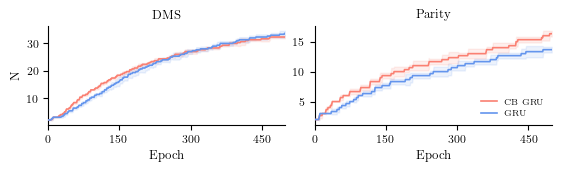

In [25]:
task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss",  
    log_y2=True,
    sharey_top=False,
    shade_auc=False,
    fig_height=1.6,
    shade_sem=True,
    sharey_bottom=True,
    save_path=None
)


## Appendix D

### Figure 8

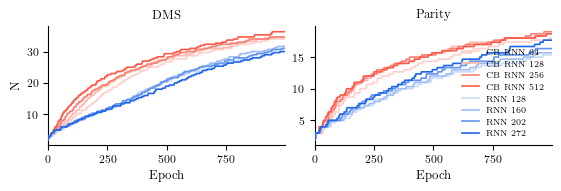

In [26]:
single_task_DMS_DIR = RESULTS_DIR / "single_task/dms_multistyle_repeats"
single_task_PARITY_DIR = RESULTS_DIR / "single_task/parity_multistyle_repeats"

groups = {
    "CB RNN 64": {
        "pattern": "gc64_RNNlr0.01_CBlr0.01_CBinput_simult",
        "color": "#FFD0CB"
    },
    "CB RNN 128": {
        "pattern": "gc128_RNNlr0.01_CBlr0.01_CBinput",
        "color": "#FFB9B1"
    },
    "CB RNN 256": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult",
        "color": "salmon"
    },
    "CB RNN 512": {
        "pattern": "gc512_RNNlr0.01_CBlr0.01_CBinput",
        "color": "#FF5947"
    },
    "RNN 128": {
        "pattern": "elman_size_128_noCB",
        "color": "#CADBF9"
    },
    "RNN 160": {
        "pattern": "elman_size_160_noCB",
        "color": "#9EBDF4"
    },
    "RNN 202": {
        "pattern": "elman_size_202_noCB",
        "color": "cornflowerblue"
    },
    "RNN 272": {
        "pattern": "elman_size_272_noCB",
        "color": "#1F67E7"
    },
}

task_dirs = {
    "DMS": single_task_DMS_DIR,
    "Parity": single_task_PARITY_DIR,
}

clip_lens = {
    "DMS": 1000,
    "Parity": 1000,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity",
}

task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss",  
    log_y2=True,
    sharey_top=False,
    max_runs=3, # limit to 3 runs per group for plotting fairness
    shade_auc=False,
    fig_height=1.8,
    shade_sem=False,
    sharey_bottom=True,
    save_path=None
)


### Figure 9


DMS
GC64 - RNN128: 4418.8333 ± 1006.1504 SD, n=3
GC256 - RNN202: 5880.1667 ± 612.0744 SD, n=3

Parity
GC64 - RNN128: 2711.0000 ± 523.7242 SD, n=3
GC256 - RNN202: 2872.3333 ± 280.4177 SD, n=3


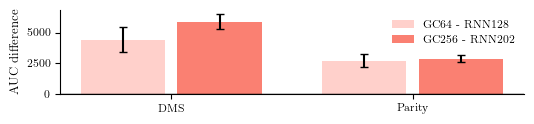

In [27]:
from analysis.single_task_plotting_utils import compute_auc_differences_all_pairs, plot_auc_differences_all_pairs

matched_pairs = {
    "GC64 - RNN128": ("CB RNN 64", "RNN 128"),
    "GC256 - RNN202": ("CB RNN 256", "RNN 202"),
}
df_auc_diffs = compute_auc_differences_all_pairs(
    task_aggs=task_aggs1,
    task_dirs=task_dirs,
    matched_pairs=matched_pairs,
)
fig, ax = plot_auc_differences_all_pairs(
    df_auc_diffs,
    pair_order=[
        "GC64 - RNN128",
        "GC256 - RNN202",
    ],
    figsize=None,
    fig_height=1.4,
    save_path=None,
)


## Appendix E

### E.1 Figure 10

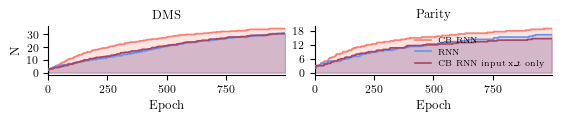

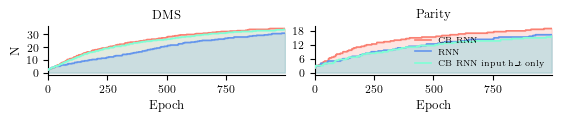

In [28]:
dms_dir = RESULTS_DIR / "single_task/dms_multistyle_repeats"

parity_dir = RESULTS_DIR / "single_task/parity_multistyle_repeats"

groups = {
    "CB RNN": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult",
        "color": "salmon"
    },
    "RNN": {
        "pattern": "elman_size_202_noCB",
        "color": "cornflowerblue"
    },
    "CB RNN input x_t only": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_noH",
        "color": "#AA4465"
    },
}

task_dirs = {
    "DMS": dms_dir,
    "Parity": parity_dir,
}

clip_lens = {
    "DMS": 1000,
    "Parity": 1000,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity",
}

task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss", 
    log_y2=True,
    max_runs=3,
    sharey_top=False,
    shade_auc=True,
    fig_height=1.1,
    shade_sem=False,
    sharey_bottom=True,
)
groups = {
    "CB RNN": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult",
        "color": "salmon"
    },
    "RNN": {
        "pattern": "elman_size_202_noCB",
        "color": "cornflowerblue"
    },
    "CB RNN input h_t only": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_network",
        "color": "aquamarine"
    },
}

task_dirs = {
    "DMS": dms_dir,
    "Parity": parity_dir,
}

clip_lens = {
    "DMS": 1000,
    "Parity": 1000,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity",
}

task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss", 
    log_y2=True,
    sharey_top=False,
    max_runs=3, 
    shade_auc=True,
    fig_height=1.1,
    shade_sem=False,
    sharey_bottom=True,
)


### E.2 Figure 11

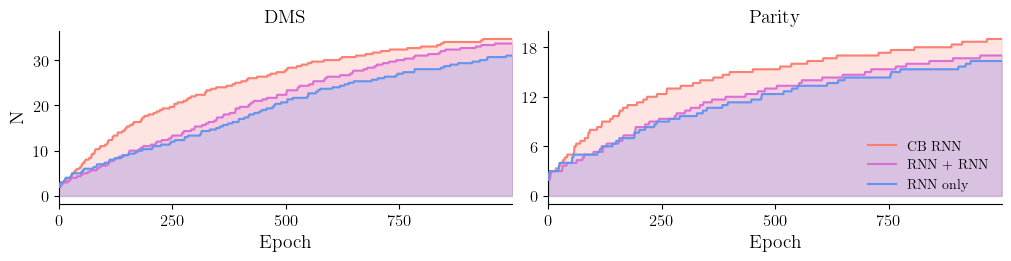

/tmp/ipykernel_2891852/1401565560.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(t)}' for t in ax.get_yticks()], fontsize=8)
/tmp/ipykernel_2891852/1401565560.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(t)}' for t in ax.get_yticks()], fontsize=8)


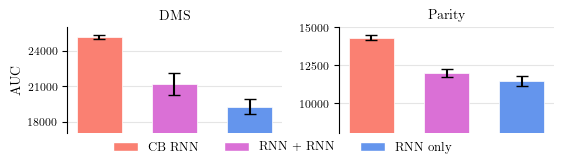

In [29]:
from analysis.single_task_plotting_utils import _collect_runs, average_and_plot_runs, average_and_plot_runs_multitask

single_task_DMS_DIR = RESULTS_DIR / "single_task/dms_multistyle_repeats"
single_task_PARITY_DIR = RESULTS_DIR / "single_task/parity_multistyle_repeats"

groups = {
    "CB RNN": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult_net",
        "color": "salmon"
    },
    "RNN + RNN": {
        "pattern": "elman_size_64_auxH139_RNNlr0.01_CBlr0.01_CBinput_net",
        "exclude": "network_1",
        "color": "orchid"
    },
    "RNN only": {
        "pattern": "elman_size_202_noCB",
        "color": "cornflowerblue"
    },
}

task_dirs = {
    "DMS": single_task_DMS_DIR,
    "Parity": single_task_PARITY_DIR,
}

clip_lens = {
    "DMS": 1000,
    "Parity": 1000,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity",
}

task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss",
    plot_lower_metric=False,
    log_y2=True,
    figsize=(10, 2.5),
    big_font=True,
    sharey_top=False,
    shade_auc=True,
    max_runs=3,
    fig_height=0.9,
    shade_sem=False,
    sharey_bottom=True,
    save_path=None
)
from matplotlib.patches import Patch

# Colors
COLORS = {'CB RNN': 'salmon', 'RNN + RNN': 'orchid', 'RNN only': 'cornflowerblue'}
model = ('CB RNN', 'RNN + RNN', 'RNN only')
tasks = ['DMS', 'Parity']

AUC_vals = {
    task: {m: task_aggs1[task][m]['auc'] for m in model}
    for task in tasks
}

def mean_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return np.nanmean(x), np.nanstd(x) 

bar_width = 0.6

fig, axes = plt.subplots(1, len(tasks), figsize=(5.8, 1.6))

for ax, task in zip(axes, tasks):
    means, stds = [], []
    for m in model:
        mean, sem = mean_std(AUC_vals[task][m])
        means.append(mean)
        stds.append(sem)

    x_positions = np.arange(len(model))
    ax.bar(
        x_positions, means, width=bar_width,
        yerr=stds, capsize=4,
        color=[COLORS[m] for m in model],
        edgecolor='white', linewidth=0.5,
        zorder=3,
    )

    ax.set_xticks([])
    ax.set_title(task, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(axis='y', color='#e5e5e5', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    hi = max(m + s for m, s in zip(means, stds)) * 1.05
    lo = min(means) * 0.5  
    ax.set_ylim(lo, hi)
    if ax is axes[0]:
        ax.set_ylabel('AUC', fontsize=10)
        ax.set_ylim(17000, 26000)
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=3, prune='lower'))
        ax.set_yticklabels([f'{int(t)}' for t in ax.get_yticks()], fontsize=8)


    if ax is axes[1]:
        ax.set_ylim(8000, 15000)
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=3, prune='lower'))
        ax.set_yticklabels([f'{int(t)}' for t in ax.get_yticks()], fontsize=8)


legend_handles = [Patch(facecolor=COLORS[m], edgecolor='white', label=m) for m in model]
fig.legend(
    handles=legend_handles, labels=list(model),
    loc='lower center', ncol=len(model),
    frameon=False, fontsize=9,
    bbox_to_anchor=(0.5, -0.08),
)

fig.tight_layout()
plt.show()



## Appendix G

### Figure 12

Processing timescales: task=dms, regime=simultaneous
Processing timescales: task=dms, regime=reservoir
Processing timescales: task=parity, regime=simultaneous
Processing timescales: task=parity, regime=reservoir


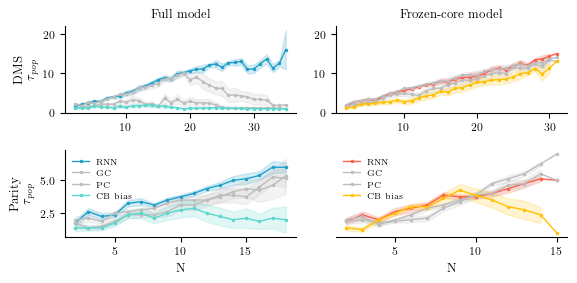

(<Figure size 590x300 with 4 Axes>,
 array([<Axes: title={'center': 'Full model'}, ylabel='DMS\n$\\tau_{pop}$'>,
        <Axes: title={'center': 'Frozen-core model'}>,
        <Axes: xlabel='N', ylabel='Parity\n$\\tau_{pop}$'>,
        <Axes: xlabel='N'>], dtype=object))

In [30]:
from analysis.timescales import summarize_timescale_multiple_runs, average_across_runs_timescales


NETWORKS = range(1, 9) 


def make_network_paths(base_dir, pattern, networks=NETWORKS):
    base_dir = RESULTS_DIR / base_dir
    return [str(base_dir / pattern.format(i=i)) for i in networks]


RUN_GROUPS = {
    ("dms", "simultaneous"): make_network_paths(
        "single_task/dms_multistyle_repeats",
        "single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
    ),

    ("dms", "reservoir"): make_network_paths(
        "reservoir_comparisons/dms",
        "alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_{i}",
    ),

    ("parity", "simultaneous"): make_network_paths(
        "single_task/parity_multistyle_repeats",
        "single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
    ),

    ("parity", "reservoir"): make_network_paths(
        "reservoir_comparisons/parity",
        "alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_{i}",
    ),
}

timescale_runs = {}
avg_timescales = {}

for (task, regime), paths in RUN_GROUPS.items():
    print(f"Processing timescales: task={task}, regime={regime}")

    df_runs = summarize_timescale_multiple_runs(paths)
    df_runs["task"] = task
    df_runs["regime"] = regime

    df_avg = average_across_runs_timescales(df_runs)
    df_avg["task"] = task
    df_avg["regime"] = regime

    timescale_runs[(task, regime)] = df_runs
    avg_timescales[(task, regime)] = df_avg

from analysis.timescales import plot_two_task_full_vs_reservoir_e_folding_2x2
timescale_runs_df = timescale_runs[("dms", "simultaneous")]
avg_timescale_df = avg_timescales[("dms", "simultaneous")]

timescale_runs_res_df = timescale_runs[("dms", "reservoir")]
avg_timescale_res_df = avg_timescales[("dms", "reservoir")]

timescale_runs_par_df = timescale_runs[("parity", "simultaneous")]
avg_timescale_par_df = avg_timescales[("parity", "simultaneous")]

timescale_runs_par_res_df = timescale_runs[("parity", "reservoir")]
avg_timescale_par_res_df = avg_timescales[("parity", "reservoir")]

plot_two_task_full_vs_reservoir_e_folding_2x2(
    avg_df_full_task1=avg_timescale_df,
    avg_df_res_task1=avg_timescale_res_df,
    avg_df_full_task2=avg_timescale_par_df,
    avg_df_res_task2=avg_timescale_par_res_df,
    fig_height=1.9,
    figsize=(5.9, 3),
    show_top_right_yticklabels=True,
    savepath=None,
    ylim_vals=None,
)

## Appendix H

### Figure 13

Running PCA summary: task=dms, regime=simultaneous
Processing run 1/8: single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Processing run 2/8: single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Processing run 3/8: single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_3
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Runn

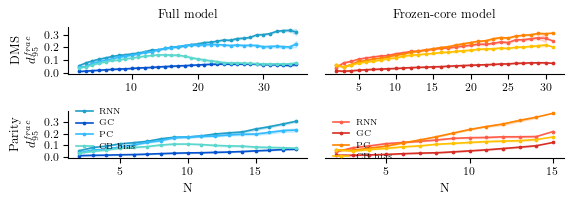

(<Figure size 590x220 with 4 Axes>,
 array([<Axes: title={'center': 'Full model'}, ylabel='DMS\n $d_{95}^{frac}$'>,
        <Axes: title={'center': 'Frozen-core model'}>,
        <Axes: xlabel='N', ylabel='Parity\n $d_{95}^{frac}$'>,
        <Axes: xlabel='N'>], dtype=object))

In [31]:
from tasks.task_generators import make_batch_mtstyle_dms, make_batch_mtstyle_parity
from analysis.pca_dimensionality import summarize_multi_runs_pca_for_multi_keys
import re

COMMON_KWARGS = dict(
    keys=["hidden", "gc", "pc", "cb_bias"],
    batch_size=64,
    n_batches=10,
    head_idx=0,
    device="cpu",
)

def make_network_paths(base_dir, pattern):
    base_dir = RESULTS_DIR / base_dir
    glob_pattern = pattern.format(i="*")
    matches = sorted(
        base_dir.glob(glob_pattern),
        key=lambda p: int(re.search(r"network_(\d+)", p.name).group(1)),
    )
    return [str(p) for p in matches]

RUN_GROUPS = {
    ("dms", "simultaneous"): {
        "paths": make_network_paths(
            "single_task/dms_multistyle_repeats",
            "single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_dms,
    },

    ("dms", "reservoir"): {
        "paths": make_network_paths(
            "reservoir_comparisons/dms",
            "alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_dms,
    },

    ("parity", "simultaneous"): {
        "paths": make_network_paths(
            "single_task/parity_multistyle_repeats",
            "single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_parity,
    },

    ("parity", "reservoir"): {
        "paths": make_network_paths(
            "reservoir_comparisons/parity",
            "alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_parity,
    },
}


results = {}

for (task, regime), cfg in RUN_GROUPS.items():
    print(f"Running PCA summary: task={task}, regime={regime}")

    df = summarize_multi_runs_pca_for_multi_keys(
        run_paths=cfg["paths"],
        batch_fn=cfg["batch_fn"],
        **COMMON_KWARGS,
    )

    df["task"] = task
    df["regime"] = regime

    results[(task, regime)] = df


all_pca_df = pd.concat(results.values(), ignore_index=True)
from analysis.pca_dimensionality import plot_two_tasks_full_vs_reservoir_pca_mean_2x2
all_df_cb_dms = results[("dms", "simultaneous")]
all_df_cb_dms_res = results[("dms", "reservoir")]
all_df_cb_parity = results[("parity", "simultaneous")]
all_df_cb_parity_res = results[("parity", "reservoir")]
plot_two_tasks_full_vs_reservoir_pca_mean_2x2(
    df_full_task1=all_df_cb_dms,
    df_res_task1=all_df_cb_dms_res,
    df_full_task2=all_df_cb_parity,
    df_res_task2=all_df_cb_parity_res,
    task1_title="DMS",
    task2_title="Parity",
    fig_height=2.5,
    figsize=(5.9, 2.2),
    metric="d95_frac",
    save_path=None
)


## Appendix I

### I.2 Table 3

In [32]:
from analysis.cb_ablation import decode_auc_over_runs_many_Ns, summarise_decode_across_runs_over_Ns, print_auc_for_N

Ns_dms = [24]
Ns_par = [8]
df_decode_dms_over_Ns = decode_auc_over_runs_many_Ns(
    all_outputs=all_outputs_dms,
    Ns=Ns_dms,
    module_key="hidden",
    conditions=("full", "ablated"),
    cv=5,
    random_state=0,
)

summary_dms_over_Ns = summarise_decode_across_runs_over_Ns(
    df_decode_dms_over_Ns
)

df_decode_parity_over_Ns = decode_auc_over_runs_many_Ns(
    all_outputs=all_outputs_par,
    Ns=Ns_par,
    module_key="hidden",
    conditions=("full", "ablated"),
    cv=5,
    random_state=0,
)

summary_parity_over_Ns = summarise_decode_across_runs_over_Ns(
    df_decode_parity_over_Ns
)

print_auc_for_N(summary_dms_over_Ns, "DMS", 24)
print_auc_for_N(summary_parity_over_Ns, "PAR", 8)


task=DMS | full | N=24 | hidden: ROC-AUC = 0.998 ± 0.003 SD across 8 runs
task=DMS | ablated | N=24 | hidden: ROC-AUC = 0.796 ± 0.031 SD across 8 runs
task=PAR | full | N=8 | hidden: ROC-AUC = 0.997 ± 0.001 SD across 8 runs
task=PAR | ablated | N=8 | hidden: ROC-AUC = 0.630 ± 0.050 SD across 8 runs


### I.3 Figure 14a


[1/8] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=2 =====
step    0 | loss=0.5544 | acc=0.9062
step   50 | loss=0.5198 | acc=1.0000

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=3 =====
step    0 | loss=0.5245 | acc=0.7969
step   50 | loss=0.5033 | acc=0.8281

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=4 =====
step    0 | loss=0.5629 | acc=0.7031
step   50 | loss=0.5119 | acc=0.8125

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=5 =====
step    0 | loss=0.7305 | acc=0.5625
step   50 | loss=0.6425 | acc=0.6406

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=6 =====
step    0 | loss=0.5975 | acc=0.6094
step   50 | loss=0.6640 | acc=0.6250

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_

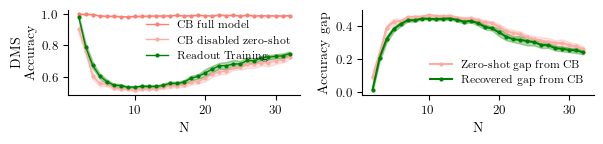

(<Figure size 620x160 with 2 Axes>,
 array([<Axes: xlabel='N', ylabel='DMS\nAccuracy'>,
        <Axes: xlabel='N', ylabel='Accuracy gap'>], dtype=object))

In [33]:
from pathlib import Path
from tasks.task_generators import make_batch_mtstyle_dms, make_batch_mtstyle_parity

from analysis.readout_recovery import (
    run_cb_disabled_readout_recovery_across_multiple_runs,
    summarize_cb_disabled_readout_recovery_across_runs,
    plot_cb_disabled_readout_recovery,
)


def make_network_paths(base_dir, pattern, networks=range(1, 9)):
    base_dir = RESULTS_DIR / base_dir
    return [str(base_dir / pattern.format(i=i)) for i in networks]

cb_dms_paths = make_network_paths(
    "reservoir_comparisons/dms",
    "single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
)

df_recovery_dms = run_cb_disabled_readout_recovery_across_multiple_runs(
    cb_run_paths=cb_dms_paths,
    batch_fn=make_batch_mtstyle_dms,
    batch_size=64,
    n_train_steps=100,
    lr=1e-2,
    head_idx=0,
    device="cpu",
    eval_batches=50,
)

summary_recovery_dms = summarize_cb_disabled_readout_recovery_across_runs(
    df_recovery_dms
)

plot_cb_disabled_readout_recovery(
    summary_recovery_dms,
    task_title="DMS",
    fig_size=(6.2, 1.6),
    fig_height=1.6,
    save_path=None
)


[1/8] single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1

===== single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=2 =====
step    0 | loss=0.6406 | acc=1.0000
step   50 | loss=0.6364 | acc=0.8906

===== single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=3 =====
step    0 | loss=0.6949 | acc=0.6250
step   50 | loss=0.6619 | acc=0.6562

===== single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=4 =====
step    0 | loss=0.7584 | acc=0.6406
step   50 | loss=0.9070 | acc=0.4688

===== single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=5 =====
step    0 | loss=2.3984 | acc=0.5156
step   50 | loss=0.8147 | acc=0.5156

===== single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=6 =====
step    0 | loss=3.2426 | acc=0.5000
step   50 | loss=0.8875 | acc=0.4375

===== single_parity_elman_size_64_CB_gc25

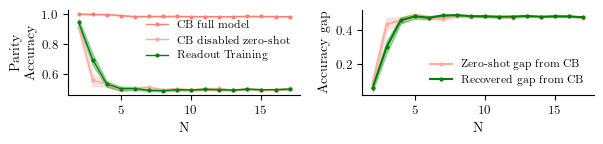

(<Figure size 620x160 with 2 Axes>,
 array([<Axes: xlabel='N', ylabel='Parity\nAccuracy'>,
        <Axes: xlabel='N', ylabel='Accuracy gap'>], dtype=object))

In [34]:
cb_parity_paths = make_network_paths(
    "reservoir_comparisons/parity",
    "single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
)

df_recovery_parity = run_cb_disabled_readout_recovery_across_multiple_runs(
    cb_run_paths=cb_parity_paths,
    batch_fn=make_batch_mtstyle_parity,
    batch_size=64,
    n_train_steps=100,
    lr=1e-2,
    head_idx=0,
    device="cpu",
    eval_batches=50,
)

summary_recovery_parity = summarize_cb_disabled_readout_recovery_across_runs(
    df_recovery_parity
)
plot_cb_disabled_readout_recovery(
    summary_recovery_parity,
    task_title="Parity",
    fig_size=(6.2, 1.6),
    fig_height=1.6,
    save_path=None
)


## Appendix K

### Table 4

In [35]:

CB_runpaths = [
    reservoir_dir / f"dms/single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}" for i in range(1, 9)
]
rnn_runpaths = [
    reservoir_dir / f"dms/single_dms_elman_size_202_noCB_RNNlr0.01_network_{i}" for i in range(1, 9)
]
CB_runpaths_fullres = [
    reservoir_dir / f"dms/alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_{i}" for i in range(1, 9)
]
CB_runpaths_intres = [
    reservoir_dir / f"dms/alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_res_network_{i}" for i in range(1, 9)
]

groups = {
    "CB-RNN": CB_runpaths,
    "RNN-only": rnn_runpaths,
    "Full reservoir": CB_runpaths_fullres,
    "Interleaved reservoir": CB_runpaths_intres,
}

single = analyse_single_task_groups(
    groups,
    filename="stats.npy",      
    epoch_budget=1000,         
)

display(single["summary"])
print("Global max N:", single["global_max_N"])


,model,n_runs,max_N_mean,max_N_sd,max_N_sem,final_N_mean,final_N_sd,final_N_sem,epochs_to_half_global_max_N_mean,epochs_to_half_global_max_N_sd,epochs_to_half_global_max_N_sem,raw_AUC_mean,raw_AUC_sd,raw_AUC_sem,mean_N_mean,mean_N_sd,mean_N_sem
0,CB-RNN,8,34.750,0.886405,0.313392,34.750,0.886405,0.313392,215.375,11.312919,3.999721,25041.2500,626.994987,221.676204,25.059625,0.627374,0.221810
1,Full reservoir,8,30.000,1.309307,0.462910,30.000,1.309307,0.462910,275.000,28.650605,10.129518,21688.5000,710.310998,251.132862,21.726226,0.711574,0.251580
2,Interleaved reservoir,8,35.625,2.445842,0.864736,35.625,2.445842,0.864736,264.375,17.344719,6.132284,23594.5625,792.429917,280.166284,23.637012,0.793955,0.280705
3,RNN-only,8,31.375,0.517549,0.182981,31.375,0.517549,0.182981,455.625,28.977516,10.245099,19253.5625,524.407110,185.405912,19.270250,0.524289,0.185364


Global max N: 38.0


In [36]:
CB_runpaths = [
    reservoir_dir / f"parity/single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}" for i in range(1, 9)
]
rnn_runpaths = [
    reservoir_dir / f"parity/single_parity_elman_size_202_noCB_RNNlr0.01_network_{i}" for i in range(1, 9)
]
CB_runpaths_fullres = [
    reservoir_dir / f"parity/alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_{i}" for i in range(1, 9)
]
CB_runpaths_intres = [
    reservoir_dir / f"parity/alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_res_network_{i}" for i in range(1, 9)
]

groups = {
    "CB-RNN": CB_runpaths,
    "RNN-only": rnn_runpaths,
    "Full reservoir": CB_runpaths_fullres,
    "Interleaved reservoir": CB_runpaths_intres,
}

single = analyse_single_task_groups(
    groups,
    filename="stats.npy",      
    epoch_budget=1000,        
)

display(single["summary"])
print("Global max N:", single["global_max_N"])


,model,n_runs,max_N_mean,max_N_sd,max_N_sem,final_N_mean,final_N_sd,final_N_sem,epochs_to_half_global_max_N_mean,epochs_to_half_global_max_N_sd,epochs_to_half_global_max_N_sem,raw_AUC_mean,raw_AUC_sd,raw_AUC_sem,mean_N_mean,mean_N_sd,mean_N_sem
0,CB-RNN,8,18.750,0.462910,0.163663,18.750,0.462910,0.163663,153.125,14.970805,5.292979,14170.6250,232.439969,82.179939,14.181000,0.232530,0.082212
1,Full reservoir,8,15.125,0.353553,0.125000,15.125,0.353553,0.125000,176.125,8.919281,3.153442,11970.6875,244.465881,86.431741,11.991241,0.244855,0.086569
2,Interleaved reservoir,8,16.750,0.707107,0.250000,16.750,0.707107,0.250000,166.250,10.593124,3.745235,12996.1250,570.935307,201.856114,13.018519,0.571777,0.202154
3,RNN-only,8,16.750,0.707107,0.250000,16.750,0.707107,0.250000,312.125,23.960906,8.471459,11505.2500,252.039538,89.109433,11.514625,0.252245,0.089182


Global max N: 19.0


#### Multitask

In [37]:
CB_runpaths = [
    multitask_dir / f"multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_MULTITASK_network_{i}" for i in range(1, 9)
]
rnn_runpaths = [
    multitask_dir / f"multitask_mt_elman_size_202_noCB_RNNlr0.01_MULTITASK_network_{i}" for i in range(1, 9)
]
CB_runpaths_fullres = [
    multitask_dir / f"multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_MULTITASK_network_{i}" for i in range(1, 9)
]
CB_runpaths_intres = [
    multitask_dir / f"multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_reservoir_MULTITASK_network_{i}" for i in range(1, 9)
]

groups = {
    "CB-RNN": CB_runpaths,
    "RNN-only": rnn_runpaths,
    "Full reservoir": CB_runpaths_fullres,
    "Interleaved reservoir": CB_runpaths_intres,
}

multi = analyse_multitask_groups(
    groups,
    filename="stats_multitask.npy",
    task_keys=("N_dms",),      
    epoch_budget=1000,
)

display(multi["summary"])
print("Global max N:", multi["global_max_N"])


,model,n_runs,mean_max_N_mean,mean_max_N_sd,mean_max_N_sem,mean_final_N_mean,mean_final_N_sd,mean_final_N_sem,mean_epochs_to_half_global_max_N_mean,mean_epochs_to_half_global_max_N_sd,mean_epochs_to_half_global_max_N_sem,mean_AUC_mean,mean_AUC_sd,mean_AUC_sem,sum_AUC_mean,sum_AUC_sd,sum_AUC_sem,mean_N_mean,mean_N_sd,mean_N_sem
0,CB-RNN,8,21.875,0.991031,0.350382,21.875,0.991031,0.350382,168.875,15.151025,5.356696,16082.4375,570.688834,201.768972,16082.4375,570.688834,201.768972,16.094375,0.571105,0.201916
1,Full reservoir,8,17.750,1.035098,0.365963,17.750,1.035098,0.365963,235.875,25.848114,9.138688,13511.2500,450.813788,159.386743,13511.2500,450.813788,159.386743,13.521125,0.451162,0.159510
2,Interleaved reservoir,8,19.250,2.434866,0.860855,19.250,2.434866,0.860855,218.750,17.244047,6.096691,14594.2500,759.270609,268.442698,14594.2500,759.270609,268.442698,14.604875,0.760364,0.268829
3,RNN-only,8,16.250,1.388730,0.490990,16.250,1.388730,0.490990,550.250,65.721816,23.236171,10856.7500,609.892848,215.629684,10856.7500,609.892848,215.629684,10.865875,0.610541,0.215859


Global max N: 23.0


#### Task switching

In [38]:
CB_runpaths = [
    switch_dir / f"ct_switch_ctswitch_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_CTSWITCH_network_{i}" for i in range(1, 9)
]
rnn_runpaths = [
    switch_dir / f"ct_switch_ctswitch_elman_size_202_noCB_RNNlr0.01_CTSWITCH_network_{i}" for i in range(1, 9)
]

CB_runpaths_fullres = [
    switch_dir / f"ct_switch_ctswitch_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_CTSWITCH_network_{i}" for i in range(1, 9)
]

groups = {
    "CB-RNN": CB_runpaths,
    "RNN-only": rnn_runpaths,
    "Full reservoir": CB_runpaths_fullres,
}

switch = analyse_switch_groups(
    groups,
    filename="stats_continual.npy",
    tasks=("dms", "parity"),
    first_task="dms",
    second_task="parity",
    max_global_epochs=650,
)

display(switch["summary"])
print("Global max N:", switch["global_max_N"])


,model,n_runs,active_mean_N_mean,active_mean_N_sd,active_mean_N_sem,active_AUC_mean,active_AUC_sd,active_AUC_sem,active_final_N_mean,active_final_N_sd,...,n_successful_switch_phases_sem,n_total_switch_phases_mean,n_total_switch_phases_sd,n_total_switch_phases_sem,n_censored_switch_phases_mean,n_censored_switch_phases_sd,n_censored_switch_phases_sem,mean_N_gained_mean,mean_N_gained_sd,mean_N_gained_sem
0,CB-RNN,8,12.497500,0.160582,0.056774,8114.875,104.378347,36.903318,15.0,0.0,...,0.0,3.0,0.0,0.0,1.0,0.0,0.0,2.666667,0.0,0.0
1,Full reservoir,8,11.970192,0.152814,0.054028,7772.125,99.329089,35.118136,15.0,0.0,...,0.0,3.0,0.0,0.0,1.0,0.0,0.0,2.666667,0.0,0.0
2,RNN-only,8,9.848462,0.412281,0.145763,6393.000,267.982409,94.746089,15.0,0.0,...,0.0,3.0,0.0,0.0,1.0,0.0,0.0,2.666667,0.0,0.0


Global max N: 15.0
